# 4.5 注意力、FFN與殘差怎樣接成一層？


現在有四種動作：LN 整理每張位置卡，注意力讀前文，FFN 加工各卡，殘差把新修正加回舊卡。希望把它們接成能反覆使用的一層，而且輸入與輸出保持同樣的筆數、位置數與特徵寬度。

這種層塊叫 **block**。本章採「分支先整理再算」，叫 **pre-norm**，分兩段：

`u=x+Attention(LN(x))`

`y=u+FFN(LN(u))`

第一段留著 x，分支整理後讀前文，再加回修正。第二段留著 u，分支整理後加工特徵，再加回。主路沒有被 LN 永久替換；LN 在分支中。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

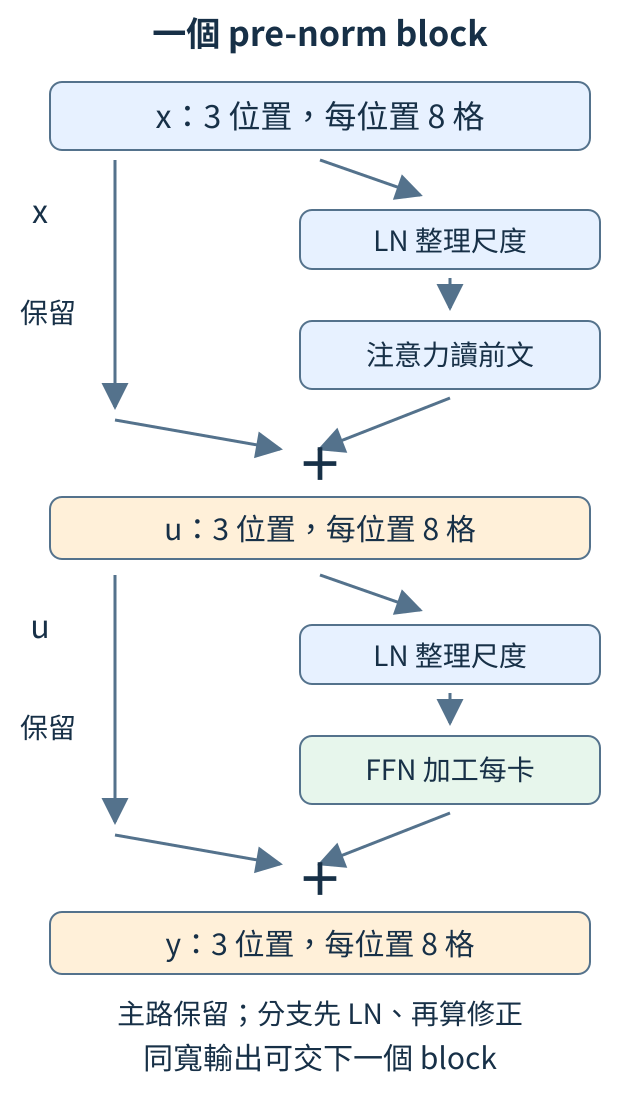

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-04-block-flow.svg")))

圖裡每條主路都是同樣三位置、每位置八格。注意力分支允許讀前文，FFN 分支在每位置獨立算；最後的輸出可交下一個同寬 block。


In [3]:
import torch
from tiny_perceptron.model import Block, ModelConfig

torch.manual_seed(42)
config = ModelConfig(width=8)
block = Block(config)
x = torch.randn(2, 3, 8)
y, cache, auxiliary = block(x)
print("輸入", x.shape, "輸出", y.shape)
print("額外代價", auxiliary.item())
assert y.shape == x.shape

輸入 torch.Size([2, 3, 8]) 輸出 torch.Size([2, 3, 8])
額外代價 0.0


`ModelConfig(width=8)` 記錄模型設定，這次每位置八格，其他用預設。輸入兩筆、三位置、每位置八格，輸出也為 `[2,3,8]`。數值已經過兩次修正，相同形狀不表示內容沒變。

兩行輸出是「輸入/輸出 `torch.Size([2,3,8])`」與「額外代價 `0.0`」。工具還回傳快取 `cache` 以及額外代價 `auxiliary`；本章 Dense 沒有那項附加代價，所以為 0，**不是答案 loss 為 0**。現在甚至還沒與正確下一字比較。

本節只檢查連線和形狀，隨機輸出不說明語言能力。練習只把筆數 2 改成 1，輸出應變 `[1,3,8]`；把位置數 3 改成 4，則變 `[2,4,8]`。改寬度則需模型設定一起改，因為各配方的輸入格數必須吻合。

<details>
<summary>補充與重做</summary>

快取是儲存的 K/V，見 [3.7](https://birdhackor.github.io/tiny-perceptron-vlm/3.7.html)。另有先計算並相加、再正規化的 post-norm 排列，順序會改計算路徑；本節只用 pre-norm。`auxiliary.item()` 將單個額外代價取成 Python 數字，不會更新參數。

</details>
